In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

n_class0 = 200
n_class1 = 1000

X0 = np.random.randn(n_class0, 5)
X1 = np.random.randn(n_class1, 5)

y0 = np.zeros(n_class0)
y1 = np.ones(n_class1)

X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(5)])
df["target"] = y

for col in df.columns[:3]:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

X = df.drop("target", axis=1)
y = df["target"]

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

importances = rf_model.feature_importances_

for i, score in enumerate(importances):
    print(f"Feature {i} Importance: {score:.4f}")

Confusion Matrix:
[[  1  39]
 [  0 200]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.03      0.05        40
         1.0       0.84      1.00      0.91       200

    accuracy                           0.84       240
   macro avg       0.92      0.51      0.48       240
weighted avg       0.86      0.84      0.77       240

Feature 0 Importance: 0.2049
Feature 1 Importance: 0.1980
Feature 2 Importance: 0.1916
Feature 3 Importance: 0.2112
Feature 4 Importance: 0.1944


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

np.random.seed(42)

n_students = 500

study_hours = np.random.normal(5, 2, n_students)
attendance = np.random.normal(75, 10, n_students)
assignments = np.random.normal(70, 15, n_students)

pass_probability = (
    0.4 * study_hours +
    0.3 * (attendance / 10) +
    0.3 * (assignments / 10)
)

threshold = np.median(pass_probability)
result = (pass_probability > threshold).astype(int)

data = pd.DataFrame({
    "study_hours": study_hours,
    "attendance": attendance,
    "assignments_score": assignments,
    "pass_exam": result
})

for col in ["study_hours", "attendance"]:
    data.loc[data.sample(frac=0.05).index, col] = np.nan

X = data.drop("pass_exam", axis=1)
y = data["pass_exam"]

imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9

Confusion Matrix:
[[43  7]
 [ 3 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.90        50
           1       0.87      0.94      0.90        50

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
data = pd.read_csv(url)

X = data.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
y = data["Exited"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.863


In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
data = pd.read_csv(url)

X = data.drop(columns=["Exited"])
y = data["Exited"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print(X.head())
print(y.head())

Features shape: (10000, 13)
Labels shape: (10000,)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  
0        101348.88  
1        112542.58  
2        113931.57  
3         93826.63  
4 

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
data = pd.read_csv(url)

X = data.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
y = data["Exited"]

X = pd.get_dummies(X, drop_first=True)

print(X.head())
print("Converted feature shape:", X.shape)

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0               1        101348.88              False            False   
1               1        112542.58              False             True   
2               0        113931.57              False            False   
3               0         93826.63              False            False   
4               1         79084.10              False             True   

   Gender_Male  
0        False  
1        False  
2        False  
3        False  
4        False  
Converted feature shape: (10000, 11)


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
data = pd.read_csv(url)

X = data.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
y = data["Exited"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training feature shape: (8000, 11)
Testing feature shape: (2000, 11)
Training labels shape: (8000,)
Testing labels shape: (2000,)


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
data = pd.read_csv(url)

X = data.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
y = data["Exited"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaled training data shape:", X_train.shape)
print("Scaled testing data shape:", X_test.shape)

Scaled training data shape: (8000, 11)
Scaled testing data shape: (2000, 11)


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
data = pd.read_csv(url)

X = data.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
y = data["Exited"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.808
Confusion Matrix:
[[1540   53]
 [ 331   76]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [22]:


url = "https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv"
data = pd.read_csv(url)

X = data.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
y = data["Exited"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8635
Confusion Matrix:
[[1536   57]
 [ 216  191]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1
Cluster Centers:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


c:\Users\LAPPYFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


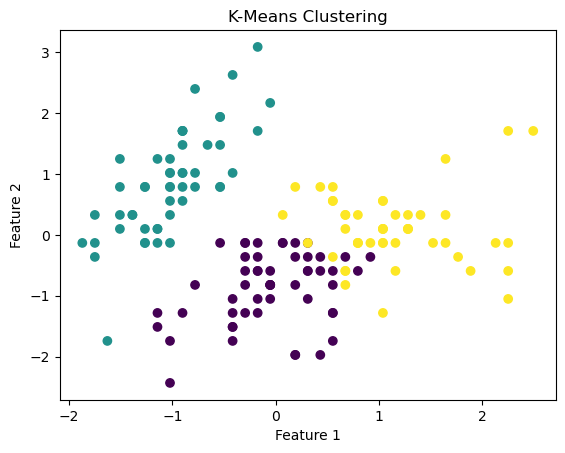

In [23]:


url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
data = pd.read_csv(url)

X = data.drop(columns=["species"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

data["Cluster"] = clusters

print(data.head())
print("Cluster Centers:")
print(kmeans.cluster_centers_)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

   Annual Income (k$)  Spending Score (1-100)
0                 117                      52
1                  66                      96
2                 107                       4
3                  29                      94
4                 121                      23


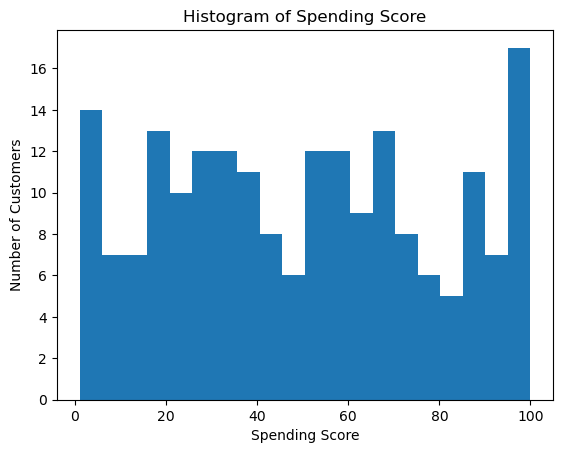

In [21]:


np.random.seed(42)

n_customers = 200

annual_income = np.random.randint(15, 140, n_customers)
spending_score = np.random.randint(1, 101, n_customers)

data = pd.DataFrame({
    "Annual Income (k$)": annual_income,
    "Spending Score (1-100)": spending_score
})

print(data.head())

plt.hist(data["Spending Score (1-100)"], bins=20)
plt.title("Histogram of Spending Score")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

   Age  Spending Score (1-100)
0   56                      70
1   69                      72
2   46                      27
3   32                       9
4   60                      62


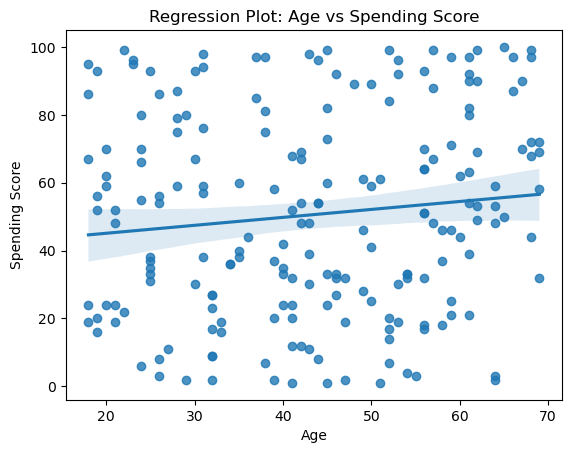

In [20]:


np.random.seed(42)

n_customers = 200

age = np.random.randint(18, 70, n_customers)
spending_score = np.random.randint(1, 101, n_customers)

data = pd.DataFrame({
    "Age": age,
    "Spending Score (1-100)": spending_score
})

print(data.head())

sns.regplot(x="Age", y="Spending Score (1-100)", data=data)

plt.title("Regression Plot: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

c:\Users\LAPPYFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LAPPYFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LAPPYFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LAPPYFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

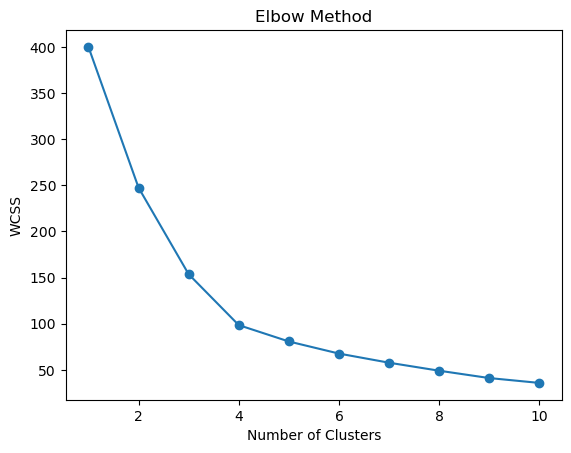

In [24]:

np.random.seed(42)

n_customers = 200
annual_income = np.random.randint(15, 140, n_customers)
spending_score = np.random.randint(1, 101, n_customers)

data = pd.DataFrame({
    "Annual Income (k$)": annual_income,
    "Spending Score (1-100)": spending_score
})

X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [25]:


np.random.seed(42)

n_customers = 200
annual_income = np.random.randint(15, 140, n_customers)
spending_score = np.random.randint(1, 101, n_customers)

data = pd.DataFrame({
    "Annual Income (k$)": annual_income,
    "Spending Score (1-100)": spending_score
})

X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
data["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_1_data = data[data["Cluster"] == 1]

print(cluster_1_data)

     Annual Income (k$)  Spending Score (1-100)  Cluster
7                    35                      29        1
20                   36                       6        1
21                   67                      28        1
22                   16                      28        1
25                   44                      30        1
40                   73                       9        1
45                   29                      44        1
56                   17                      12        1
58                   65                       2        1
59                   21                       3        1
63                   32                       2        1
64                   18                       2        1
70                   23                       1        1
72                   67                       2        1
83                   49                      17        1
90                   16                      11        1
91                   20        

c:\Users\LAPPYFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [26]:

np.random.seed(42)

n_customers = 200
annual_income = np.random.randint(15, 140, n_customers)
spending_score = np.random.randint(1, 101, n_customers)

data = pd.DataFrame({
    "Annual Income (k$)": annual_income,
    "Spending Score (1-100)": spending_score
})

X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
data["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = data.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

target_cluster = cluster_summary["Annual Income (k$)"].idxmax()
target_cluster = cluster_summary.loc[[target_cluster]].index[0]

high_value_customers = data[data["Cluster"] == target_cluster]

print("Target Cluster (High Income & High Spending):", target_cluster)
print(high_value_customers.head())
print("Total Customers to Target:", len(high_value_customers))

Target Cluster (High Income & High Spending): 0
    Annual Income (k$)  Spending Score (1-100)  Cluster
11                 101                      71        0
15                 131                      66        0
24                 122                      84        0
35                 139                      77        0
37                 103                      70        0
Total Customers to Target: 33


c:\Users\LAPPYFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
